In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import os


In [2]:
df = pd.read_csv("../data/shared_50k_tweets.csv")
df["date"] = pd.to_datetime(df["date"])
print("Loaded:", len(df), "tweets")
print(df.columns.tolist())

Loaded: 50000 tweets
['user_name', 'date', 'text', 'hashtags', 'mentions', 'clean_text']


In [3]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if isinstance(text, str):
        score = analyzer.polarity_scores(text)
        return score['compound']
    return 0

df['sentiment_score'] = df['clean_text'].apply(get_sentiment)

def label_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['sentiment_score'].apply(label_sentiment)

print(df['sentiment_label'].value_counts())
print("\nAverage sentiment score:", round(df['sentiment_score'].mean(), 4))

sentiment_label
Neutral     28332
Positive    16932
Negative     4736
Name: count, dtype: int64

Average sentiment score: 0.1467


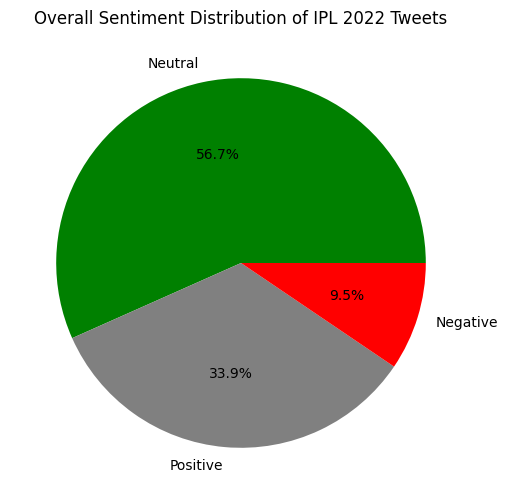

In [5]:
counts = df['sentiment_label'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', 
        colors=['green', 'gray', 'red'])
plt.title("Overall Sentiment Distribution of IPL 2022 Tweets")

plt.show()

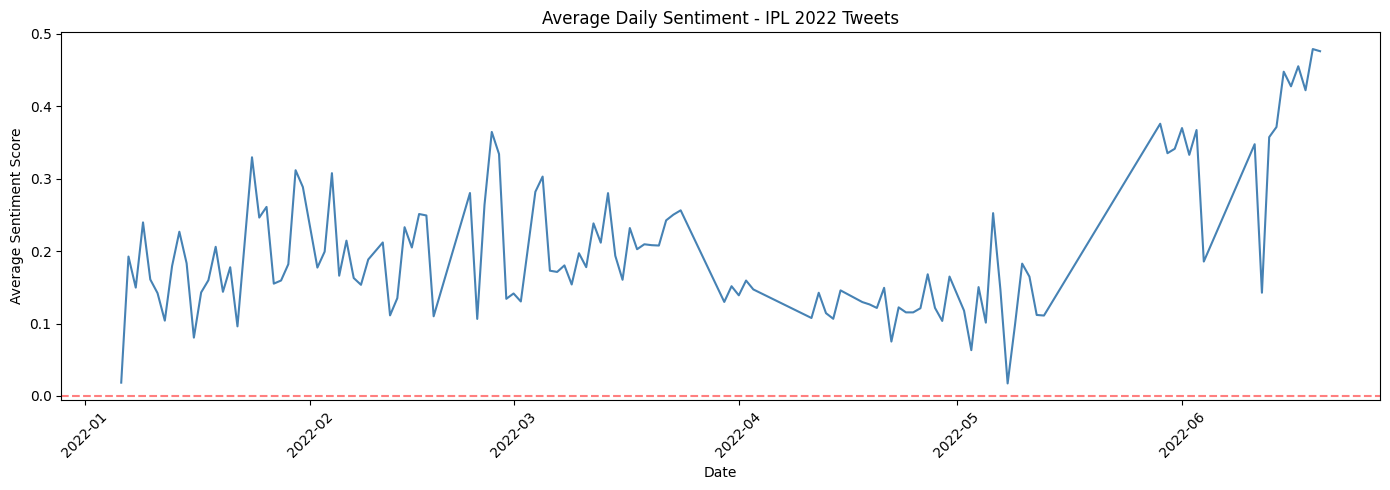

In [6]:
df['date_only'] = df['date'].dt.date
daily_sentiment = df.groupby('date_only')['sentiment_score'].mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_sentiment.index, daily_sentiment.values, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.title("Average Daily Sentiment - IPL 2022 Tweets")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [7]:
!pip install gensim
import gensim
from gensim import corpora
from gensim.models import LdaModel
from gensim.parsing.preprocessing import STOPWORDS
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english')).union(STOPWORDS)

# Add IPL specific stopwords
custom_stops = {'ipl', 'ipl2022', 'cricket', 't20', 'match', 'team', 
                'play', 'player', 'game', 'https', 'co', 'amp'}
stop_words = stop_words.union(custom_stops)

def preprocess(text):
    if not isinstance(text, str):
        return []
    tokens = text.lower().split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 3]
    return tokens

df['tokens'] = df['clean_text'].apply(preprocess)
print("Sample tokens:", df['tokens'].head(3))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 6.6 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Sample tokens: 0    [playing, picks, batting, orders, esply, power...
1      [thank, wonderful, messages, kindness, humbled]
2             [ans14, balls, vifanofthematch, lsgvcsk]
Name: tokens, dtype: object


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sahilchoudhary/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
dictionary = corpora.Dictionary(df['tokens'])
dictionary.filter_extremes(no_below=10, no_above=0.5)
corpus = [dictionary.doc2bow(tokens) for tokens in df['tokens']]

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=8,
    random_state=42,
    passes=10
)

print("\nTOP 8 TOPICS:")
for idx, topic in lda_model.print_topics(num_words=8):
    print(f"\nTopic {idx}: {topic}")


TOP 8 TOPICS:

Topic 0: 0.042*"iplauction" + 0.031*"players" + 0.024*"lucknow" + 0.021*"iplauction2022" + 0.020*"auction" + 0.019*"iplmegaauction2022" + 0.017*"ipl2022megaauction" + 0.016*"iplmegaauction"

Topic 1: 0.210*"vifanofthematch" + 0.074*"runs" + 0.024*"april" + 0.023*"dcvrr" + 0.021*"rcbvkkr" + 0.019*"rrvmi" + 0.019*"cskvrcb" + 0.018*"rrvgt"

Topic 2: 0.025*"dhoni" + 0.022*"msdhoni" + 0.019*"captain" + 0.018*"viratkohli" + 0.018*"kohli" + 0.018*"gujarat" + 0.017*"whistlepodu" + 0.016*"virat"

Topic 3: 0.023*"matches" + 0.016*"season" + 0.013*"teams" + 0.013*"played" + 0.013*"like" + 0.012*"good" + 0.011*"2022" + 0.011*"time"

Topic 4: 0.050*"vifanofthematch" + 0.031*"srhvgt" + 0.028*"bowlers" + 0.027*"contest" + 0.026*"join" + 0.023*"sixes" + 0.022*"mivlsg" + 0.018*"lsgvcsk"

Topic 5: 0.183*"vifanofthematch" + 0.051*"wickets" + 0.043*"runs" + 0.024*"cskvpbks" + 0.023*"kkrvpbks" + 0.021*"balls" + 0.020*"pbksvcsk" + 0.018*"lsgvrcb"

Topic 6: 0.024*"mumbaiindians" + 0.023*"mumb

In [9]:
dictionary = corpora.Dictionary(df['tokens'])
dictionary.filter_extremes(no_below=10, no_above=0.5)
corpus = [dictionary.doc2bow(tokens) for tokens in df['tokens']]

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=8,
    random_state=42,
    passes=10
)

print("\nTOP 8 TOPICS:")
for idx, topic in lda_model.print_topics(num_words=8):
    print(f"\nTopic {idx}: {topic}")


TOP 8 TOPICS:

Topic 0: 0.042*"iplauction" + 0.031*"players" + 0.024*"lucknow" + 0.021*"iplauction2022" + 0.020*"auction" + 0.019*"iplmegaauction2022" + 0.017*"ipl2022megaauction" + 0.016*"iplmegaauction"

Topic 1: 0.210*"vifanofthematch" + 0.074*"runs" + 0.024*"april" + 0.023*"dcvrr" + 0.021*"rcbvkkr" + 0.019*"rrvmi" + 0.019*"cskvrcb" + 0.018*"rrvgt"

Topic 2: 0.025*"dhoni" + 0.022*"msdhoni" + 0.019*"captain" + 0.018*"viratkohli" + 0.018*"kohli" + 0.018*"gujarat" + 0.017*"whistlepodu" + 0.016*"virat"

Topic 3: 0.023*"matches" + 0.016*"season" + 0.013*"teams" + 0.013*"played" + 0.013*"like" + 0.012*"good" + 0.011*"2022" + 0.011*"time"

Topic 4: 0.050*"vifanofthematch" + 0.031*"srhvgt" + 0.028*"bowlers" + 0.027*"contest" + 0.026*"join" + 0.023*"sixes" + 0.022*"mivlsg" + 0.018*"lsgvcsk"

Topic 5: 0.183*"vifanofthematch" + 0.051*"wickets" + 0.043*"runs" + 0.024*"cskvpbks" + 0.023*"kkrvpbks" + 0.021*"balls" + 0.020*"pbksvcsk" + 0.018*"lsgvrcb"

Topic 6: 0.024*"mumbaiindians" + 0.023*"mumb

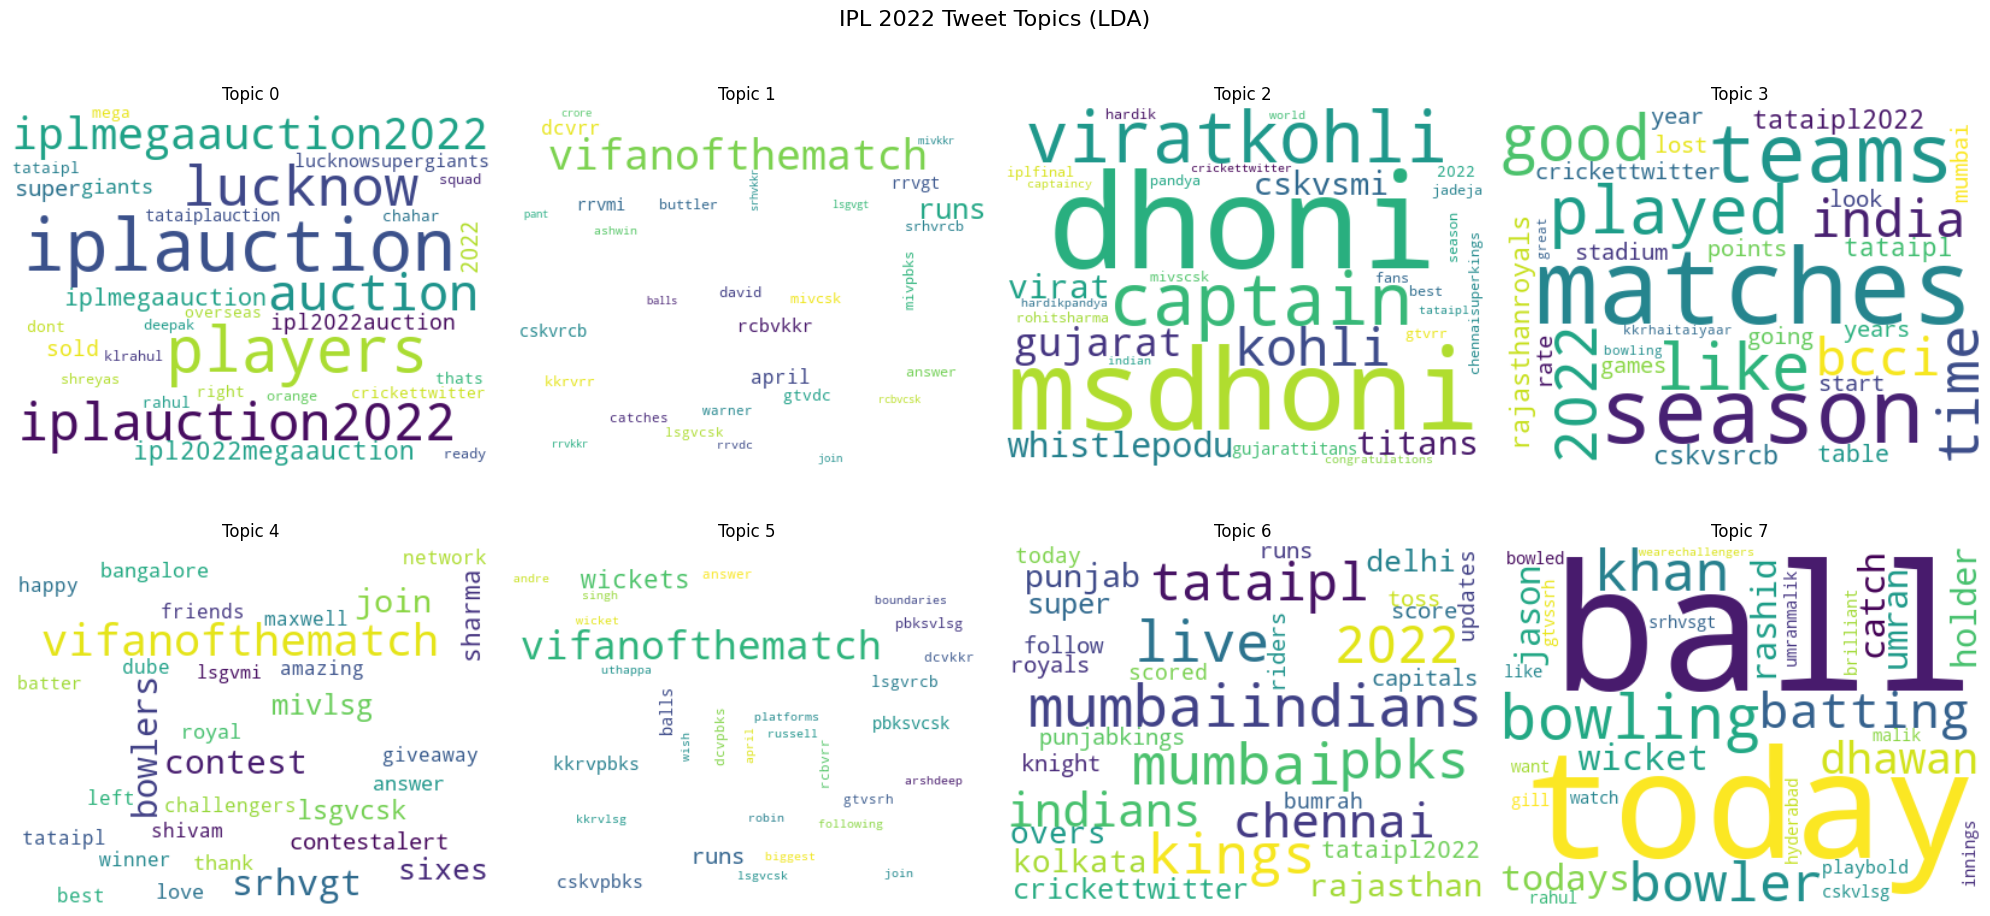

In [11]:
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx in range(8):
    topic_words = dict(lda_model.show_topic(idx, topn=30))
    wc = WordCloud(background_color='white', width=400, height=300)
    wc.generate_from_frequencies(topic_words)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f"Topic {idx}", fontsize=12)
    axes[idx].axis('off')

plt.suptitle("IPL 2022 Tweet Topics (LDA)", fontsize=16)
plt.tight_layout()

plt.show()